# **Olympic x Media Project (Winter Olympics)**

**Overview**

This project analyzes 120+ years of Olympic history to predict Canada's medal performance at the 2026 Winter Olympics in Milan-Cortina. Using historical data from Kaggle and GitHub Olympic datasets, we address two key objectives:

**Objectives**  
1. **Classification:** Predict whether Canada will win a medal in a given winter sport based on historical performance.
2. **Regression:** Forecast Canada's total medal count for the 2026 Winter Olympics.

#**0. Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

#**1. Datasets**

Datasets to be loaded into colab notebook are the .csv created from Winter_olympics_merge Notebooks:

- ath_base (used for training)
- res_base (used for testing)

(should we load them directly from the drive instead of uploading them?)

> **David Response:** I wouldn't recommend it, I did it before for NPRI and everytime you run it, Google ask you to allow Collab to acces your drive, is easier to upload the files in my opinion.




##**1.1 Importing**

In [ ]:
ath_base_csv = "/content/ath_base.csv"
res_base_csv = "/content/res_base.csv"

##**1.2 Loading**

In [ ]:
ath = pd.read_csv(ath_base_csv )
res = pd.read_csv(res_base_csv)

print("athlete_events shape:", ath.shape)
print("results shape:", res.shape)

athlete_events shape: (271116, 15)
results shape: (305807, 11)


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

#**2. Data Understanding**

##**2.1 Checking columns & rows**

In [ ]:
print(" ath columns:\n", ath.columns.tolist())
print("\n res columns:\n", res.columns.tolist())

 ath columns:
 ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']

 res columns:
 ['discipline', 'event', 'as', 'athlete_id', 'team', 'place', 'tied', 'medal', 'NOC', 'Season', 'Year']


In [ ]:
ath.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
res.head()

,discipline,event,as,athlete_id,team,place,tied,medal,NOC,Season,Year
0,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,NaN,17.0,True,NaN,FRA,Summer,1912
1,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,Jean Montariol,NaN,False,NaN,FRA,Summer,1912
2,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,NaN,32.0,True,NaN,FRA,Summer,1920
3,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,Jeanne Vaussard,8.0,True,NaN,FRA,Summer,1920
4,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,Jacques Brugnon,4.0,False,NaN,FRA,Summer,1920


## **2.2 checking dimensions of our datasets**

In [ ]:
ath.shape

(271116, 15)

In [ ]:
res.shape

(305807, 11)

## **2.3 filter winter season only from both datasets**

In [ ]:
# filtering winter season only from both datasets
ath_winter = ath[ath['Season'] == 'Winter']
res_winter = res[res['Season'] == 'Winter']

In [ ]:
# rechecking the shape of both datsets
print("athlete_events shape:", ath_winter.shape)
print("results shape:", res_winter.shape)

athlete_events shape: (48564, 15)
results shape: (64509, 11)


In [ ]:
# looking at the head of both datasets
ath_winter.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
res_winter.head()

,discipline,event,as,athlete_id,team,place,tied,medal,NOC,Season,Year
13168,Bobsleigh (Bobsleigh),"Four, Men (Olympic)",Eddie Eagan,8658,United States 1,1.0,False,Gold,USA,Winter,1932
18829,Winter Pentathlon,"Winter Pentathlon, Men (Olympic (non-medal))",Derek Allhusen,11530,NaN,6.0,False,NaN,GBR,Winter,1948
22313,Bobsleigh (Bobsleigh),"Four/Five, Men (Olympic)",Charley Stoffel,12796,Switzerland 2,NaN,False,NaN,SUI,Winter,1924
22316,Bobsleigh (Bobsleigh),"Four/Five, Men (Olympic)",Charley Stoffel,12796,Switzerland 1,8.0,False,NaN,SUI,Winter,1928
22997,Bobsleigh (Bobsleigh),"Two, Women (Olympic)",Antonella Bellutti,13065,Gerda Weissensteiner,7.0,False,NaN,ITA,Winter,2002


## **2.4 filtering the results/athletes dataset**

In [ ]:
# check how many unique years we have sorted
array = res_winter['Year'].unique()
#sort in ascending order
array.sort()
print(array)

[1924 1928 1932 1936 1948 1952 1956 1960 1964 1968 1972 1976 1980 1984
 1988 1992 1994 1998 2002 2006 2010 2012 2014 2016 2018 2020 2022]


In [ ]:
array = ath_winter['Year'].unique()
#sort in ascending order
array.sort()
print(array)

[1924 1928 1932 1936 1948 1952 1956 1960 1964 1968 1972 1976 1980 1984
 1988 1992 1994 1998 2002 2006 2010 2014]


#### **Dataset Year Irregularities**

When the Winter Olympic years are sorted, two anomalies appear. First, the 1992–1994 two-year gap reflects a one-time IOC scheduling change, where the Winter and Summer Olympics stopped being held in the same year and began alternating every two years. This does not impact long-term trends.

Second, Winter events appear in 2012, 2016, and 2020, for results dataset which do not correspond to the main Winter Olympic Games. These years represent the Winter Youth Olympic Games, a separate competition for younger athletes. As such, they are not directly comparable to the primary Olympic Games. (***Credit to Dinsara***)

#### **Justification for Removing 2012, 2016, and 2020**

The Winter Youth Olympic Games differ substantially from the main Olympic Games in terms of athlete demographics, scale, and competitive context. Including these years may introduce artificial dips or irregular patterns and skew trend analysis. To maintain consistency and ensure that the analysis reflects only elite Olympic competition, the years 2012, 2016, and 2020 are excluded from the dataset.

In [ ]:
#creating a safe copy
res_winter_copy = res_winter.copy()
# removing years 2012, 2016 and 2020 from the res dataset
res_winter = res_winter[~res_winter['Year'].isin([1924, 1928, 1932, 1936, 1948,
                                                  1952, 1956, 1960, 1964, 1968,
                                                  1972, 1976, 1980, 1984, 1988,
                                                  1992, 1994, 1998, 2002, 2006,
                                                  2010, 2012, 2014, 2016, 2020])]

In [ ]:
#check how the data looks now
res_winter['Year'].unique()

array([2018, 2022])

In [ ]:
res_winter.head(10)

,discipline,event,as,athlete_id,team,place,tied,medal,NOC,Season,Year
170597,Speed Skating (Skating),"3,000 metres, Women (Olympic)",Claudia Pechstein,82053,NaN,9.0,False,NaN,GER,Winter,2018
170598,Speed Skating (Skating),"5,000 metres, Women (Olympic)",Claudia Pechstein,82053,NaN,8.0,False,NaN,GER,Winter,2018
170599,Speed Skating (Skating),"Mass Start, Women (Olympic)",Claudia Pechstein,82053,NaN,13.0,False,NaN,GER,Winter,2018
170600,Speed Skating (Skating),"Team Pursuit (6 laps), Women (Olympic)",Claudia Pechstein,82053,Germany,6.0,False,NaN,GER,Winter,2018
170601,Speed Skating (Skating),"3,000 metres, Women (Olympic)",Claudia Pechstein,82053,NaN,20.0,False,NaN,GER,Winter,2022
170602,Speed Skating (Skating),"Mass Start, Women (Olympic)",Claudia Pechstein,82053,NaN,9.0,False,NaN,GER,Winter,2022
174429,Ski Jumping (Skiing),"Normal Hill, Individual, Men (Olympic)",Janne Ahonen,83500,NaN,40.0,False,NaN,FIN,Winter,2018
174430,Ski Jumping (Skiing),"Large Hill, Individual, Men (Olympic)",Janne Ahonen,83500,NaN,27.0,False,NaN,FIN,Winter,2018
174431,Ski Jumping (Skiing),"Large Hill, Team, Men (Olympic)",Janne Ahonen,83500,Finland,8.0,False,NaN,FIN,Winter,2018
178831,Cross Country Skiing (Skiing),"30 kilometres Skiathlon, Men (Olympic)",Siarhei Dalidovich,85250,NaN,NaN,False,NaN,BLR,Winter,2018


In [ ]:
res_winter.shape

(9884, 11)

In [ ]:
res_winter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9884 entries, 170597 to 305806
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   discipline  9883 non-null   object 
 1   event       9884 non-null   object 
 2   as          9884 non-null   object 
 3   athlete_id  9884 non-null   int64  
 4   team        3623 non-null   object 
 5   place       9133 non-null   float64
 6   tied        9884 non-null   bool   
 7   medal       1276 non-null   object 
 8   NOC         9884 non-null   object 
 9   Season      9884 non-null   object 
 10  Year        9884 non-null   int64  
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 859.1+ KB


# **3. Data Preprocessing**

## **3.1 Keeping only the relevant columns for both datasets.**

### **3.1.1 ath_winter dataset**

In [ ]:
# columns_to_keep = ['NOC', 'Year', 'City', 'Sport', 'Medal']
# ath_winter = ath_winter[columns_to_keep]

display(ath_winter.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN


### **3.1.2 res_winter dataset**

Remove columns from the `res_winter` DataFrame that are not necessary for medal prediction, similar to the approach taken for `ath_winter`.


In [ ]:
# columns_to_keep_res = ['discipline', 'place', 'medal', 'NOC', 'Year']
# res_winter = res_winter[columns_to_keep_res]

display(res_winter.head())

,discipline,event,as,athlete_id,team,place,tied,medal,NOC,Season,Year
170597,Speed Skating (Skating),"3,000 metres, Women (Olympic)",Claudia Pechstein,82053,NaN,9.0,False,NaN,GER,Winter,2018
170598,Speed Skating (Skating),"5,000 metres, Women (Olympic)",Claudia Pechstein,82053,NaN,8.0,False,NaN,GER,Winter,2018
170599,Speed Skating (Skating),"Mass Start, Women (Olympic)",Claudia Pechstein,82053,NaN,13.0,False,NaN,GER,Winter,2018
170600,Speed Skating (Skating),"Team Pursuit (6 laps), Women (Olympic)",Claudia Pechstein,82053,Germany,6.0,False,NaN,GER,Winter,2018
170601,Speed Skating (Skating),"3,000 metres, Women (Olympic)",Claudia Pechstein,82053,NaN,20.0,False,NaN,GER,Winter,2022


## **3.2 Checking and fixing null values for both datasets**

### **3.2.1 ath_winter**

In [ ]:
#checking null values in ath_winter
ath_winter.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,285
Height,8314
Weight,9021
Team,0
NOC,0
Games,0
Year,0


In [ ]:
#check dtypes
ath_winter.dtypes

,0
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,int64


In [ ]:
#imputting missing values in Medal column with a 'No Medal' string

ath_winter['Medal'] = ath_winter['Medal'].fillna('No_Medal')

/tmp/ipython-input-3094839789.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ath_winter['Medal'] = ath_winter['Medal'].fillna('No_Medal')


In [ ]:
#check unique values in medal column

ath_winter['Medal'].unique()

array(['No_Medal', 'Bronze', 'Gold', 'Silver'], dtype=object)

In [ ]:
#check missing values again

ath_winter.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,285
Height,8314
Weight,9021
Team,0
NOC,0
Games,0
Year,0


### **3.2.2. Aggregation of Relevant information**

In this section, we create aggregated metrics for each National Olympic Committee (NOC) per year. These metrics will help us analyze participation patterns and success rates across different countries and Olympic games.

#### **3.2.1.1. Counting Unique Events per NOC per Year**

**Objective:** Determine how many different events each country participated in during each Olympic year.

**Method:** We use `groupby()` with `transform('nunique')` to count unique events while preserving the original DataFrame structure.

In [ ]:
# count event per NOC per year,
# each row corresponding to a NOC in a given year will display the total amount
#of events that the NOC is participating in set year.

# Count unique events per NOC per year
ath_winter['unique_event_count'] = ath_winter.groupby(['NOC', 'Year'])['Event'].transform('nunique')

#display
display(ath_winter.head(20))

/tmp/ipython-input-3974540116.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ath_winter['unique_event_count'] = ath_winter.groupby(['NOC', 'Year'])['Event'].transform('nunique')


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No_Medal,10
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,10
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No_Medal,13
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,13
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No_Medal,17
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,17
10,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10 kilometres,No_Medal,56
11,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 50 kilometres,No_Medal,56
12,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10/15 kilometres Pu...,No_Medal,56
13,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 4 x 10 kilometres R...,No_Medal,56


#### **3.2.1.2. Counting Unique Athletes per NOC per Year**

**Objective:** Determine the total number of unique athletes representing each country per Olympic year.

**Method:** We use the `ID` column with `transform('nunique')` to count distinct athletes.

> Note: We explore some mistakes using name, so we choose ID to be precise and consistent.



In [ ]:
#count total amount of unique athletes per NOC per year

# Count unique athletes per NOC per year using ID
ath_winter['unique_athlete_count'] = ath_winter.groupby(['NOC', 'Year'])['ID'].transform('nunique')

#display first rows
display(ath_winter.head(20))


/tmp/ipython-input-1377843151.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ath_winter['unique_athlete_count'] = ath_winter.groupby(['NOC', 'Year'])['ID'].transform('nunique')


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count,unique_athlete_count
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No_Medal,10,11
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,10,11
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No_Medal,13,19
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,13,19
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No_Medal,17,21
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,17,21
10,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10 kilometres,No_Medal,56,148
11,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 50 kilometres,No_Medal,56,148
12,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10/15 kilometres Pu...,No_Medal,56,148
13,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 4 x 10 kilometres R...,No_Medal,56,148


#### **3.2.1.3. Counting Male and Female Athletes per NOC per Year**

**Objective:** Analyze gender distribution of athletes for each country per Olympic year.

**Method:**
1. **De-duplication:** Create a `unique_athletes` dataframe by dropping duplicates based on `ID`, `NOC`, and `Year`.
2. **Filtering & Grouping:** Filter the unique list by `Sex` ('M' and 'F') and use `groupby().size()` to calculate counts per NOC and Year.
3. **Merging:** Use a `left` merge to join the counts back to the primary `ath_winter` dataframe.


**New Columns Created:**
- `male_count`: Total unique male athletes per NOC per year
- `female_count`: Total unique female athletes per NOC per year

**Use Cases:**
- Analyze gender equality trends over time
- Compare gender distribution across countries
- Track progress in women's participation in Winter Olympics.

In [ ]:
# Create a dataframe with unique athletes only
unique_athletes = ath_winter.drop_duplicates(subset=['ID', 'NOC', 'Year'])

# Count unique male athletes per NOC per year
male_counts = unique_athletes[unique_athletes['Sex'] == 'M'].groupby(['NOC', 'Year']).size().reset_index(name='unique_male_count')

# Count unique female athletes per NOC per year
female_counts = unique_athletes[unique_athletes['Sex'] == 'F'].groupby(['NOC', 'Year']).size().reset_index(name='unique_female_count')

# Merge back to original dataframe
ath_winter = ath_winter.merge(male_counts, on=['NOC', 'Year'], how='left')
ath_winter = ath_winter.merge(female_counts, on=['NOC', 'Year'], how='left')

# Fill NaN values with 0
ath_winter['unique_male_count'] = ath_winter['unique_male_count'].fillna(0).astype(int)
ath_winter['unique_female_count'] = ath_winter['unique_female_count'].fillna(0).astype(int)

display(ath_winter.head(20))

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count
0,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No_Medal,10,11,6,5
1,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,10,11,6,5
2,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No_Medal,13,19,9,10
3,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,13,19,9,10
4,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No_Medal,17,21,13,8
5,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,17,21,13,8
6,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10 kilometres,No_Medal,56,148,98,50
7,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 50 kilometres,No_Medal,56,148,98,50
8,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 10/15 kilometres Pu...,No_Medal,56,148,98,50
9,6,Per Knut Aaland,M,31.0,188.0,75.0,United States,USA,1992 Winter,1992,Winter,Albertville,Cross Country Skiing,Cross Country Skiing Men's 4 x 10 kilometres R...,No_Medal,56,148,98,50


In [ ]:
# ''' Count the total amount of medals per NOC per year using the Medal column
# and adding a new column displaying the total amount per NOC per year'''

# # Count only Gold, Silver, Bronze medals per NOC per year
# ath_winter['medal_count'] = ath_winter.groupby(['NOC', 'Year'])['Medal'].transform(
#     lambda x: x.isin(['Gold', 'Silver', 'Bronze']).sum())

# display(ath_winter.head(20))

#### **3.2.1.4. Counting Medals per NOC per Year**

**Objective:** Calculate the total number of medals won by each country per Olympic year.

**Challenge:** Since for teams sports (e.g., Ice Hockey), each athlete on the winning team has a medal record, this inflate our results.

**Solution:** Remove duplicates by filtering on unique combinations of:
- `Event`
- `NOC`
- `Year`
- `Medal`

This ensures each medal is counted only **once** regardless of team size.

**Process:**
1. Filter out 'No_Medal' entries
2. Remove duplicate medal records using `drop_duplicates()`
3. Count medals per NOC per year
4. Merge counts back to original DataFrame
5. Fill missing values with 0 (for NOCs with no medals)

In [ ]:

#show medals
# First, create a dataframe with unique medal combinations (excluding 'No_Medal')
#unique_medals = ath_winter[ath_winter['Medal'] != 'No_Medal'].drop_duplicates(
#    subset=['Event', 'NOC', 'Year', 'Medal']
#)

# Count unique medals per NOC per year
#medal_counts = unique_medals.groupby(['NOC', 'Year']).size().reset_index(name='total_medal_year_noc')

# Merge back to original dataframe
#ath_winter = ath_winter.merge(medal_counts, on=['NOC', 'Year'], how='left')

# Fill NaN values (NOCs with no medals) with 0
#ath_winter['total_medal_year_noc'] = ath_winter['medal_count'].fillna(0).astype(int)

#display(ath_winter.head(20))

In [ ]:
#starting from clean winter athlete dataset
#keeping only real medals (dropping No_Medal rows)
medals_only = ath_winter[
    ath_winter["Medal"].isin(["Gold", "Silver", "Bronze"])
].copy()                                             #creating safe working copy

#removing duplicated team medals (team events appear once per athlete)
unique_medals = medals_only.drop_duplicates(
    subset=["Event", "NOC", "Year", "Medal"]        #defining what makes a medal unique
)

#counting total medals per country per year
medal_counts = (
    unique_medals
        .groupby(["NOC", "Year"])                   #grouping at NOC-Year level
        .size()                                     #counting medal awards
        .reset_index(name="total_medals_noc_year")  #naming clearly
        .sort_values(["NOC", "Year"])               #sorting for consistency
)

#dropping old total column if it exists (avoiding _x/_y duplicates after merge)
ath_winter = ath_winter.drop(
    columns=["total_medals_noc_year"],
    errors="ignore"                                 #ignoring if column does not exist
)

#merging total medals back into athlete-level dataset
ath_winter = ath_winter.merge(
    medal_counts,
    on=["NOC", "Year"],                             #matching by country and year
    how="left"                                      #keeping all athlete rows
)

#filling NaN for countries/years with zero medals
ath_winter["total_medals_noc_year"] = (
    ath_winter["total_medals_noc_year"]
    .fillna(0)                                      #replacing missing with zero
    .astype(int)                                    #ensuring integer type
)

#checking result quickly
display(ath_winter.head())                          #verifying structure looks correct

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year
0,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No_Medal,10,11,6,5,7
1,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,10,11,6,5,7
2,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No_Medal,13,19,9,10,4
3,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,13,19,9,10,4
4,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No_Medal,17,21,13,8,4


# **4. Visualisations**

## **4.1 Total number of CAN medals per year**

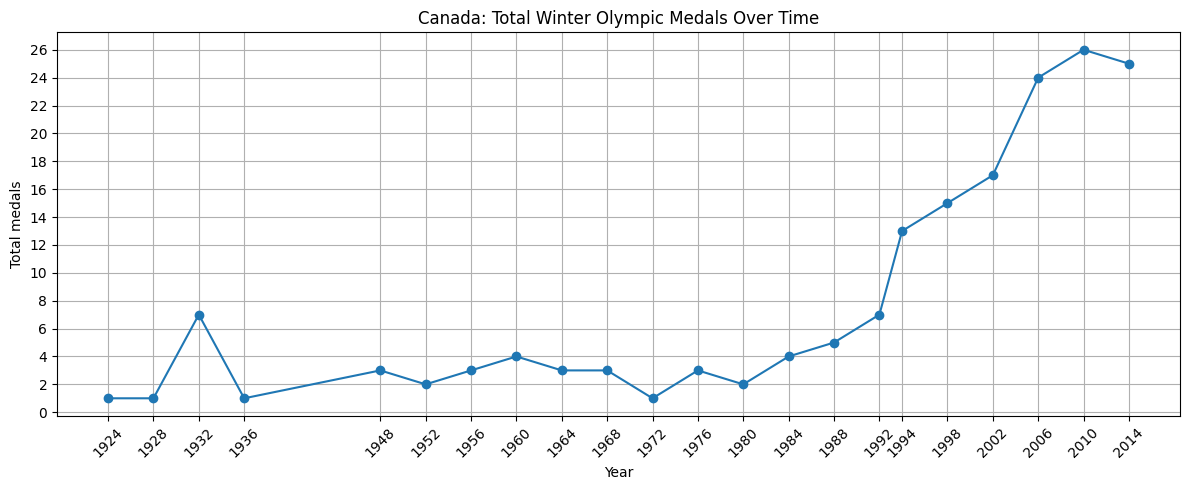

In [ ]:
#filtering Canada medal totals
can_medals = medal_counts[
    medal_counts["NOC"] == "CAN"    #keeping Canada only
].copy()

#sorting by year to keeping time chronological
can_medals = can_medals.sort_values("Year")

#creating figure with more horizontal space
plt.figure(figsize=(12, 5))         #widening figure for readability

#plotting medal trend line
plt.plot(
    can_medals["Year"],                    #x-axis values
    can_medals["total_medals_noc_year"],   #y-axis values
    marker="o"
)

#forcing every Olympic year to show
plt.xticks(
    can_medals["Year"],    #placing tick at each Olympic year
    rotation=45            #rotating labels to avoiding overlap
)

#creating more y-axis ticks (every 2 medals)
max_medals = can_medals["total_medals_noc_year"].max()  #getting max value dynamically
plt.yticks(
    np.arange(0, max_medals + 2, 2)   #creating ticks every 2 units
)

#adding labels and title
plt.title("Canada: Total Winter Olympic Medals Over Time")
plt.xlabel("Year")
plt.ylabel("Total medals")

#adding grid for visual guidance
plt.grid(True)

#adjusting layout
plt.tight_layout()

#showing final plot
plt.show()

*   Peak in 1932 (less sports competing, perhaps?)
*   Gap between 1936 and 1948 (ww2)
*   winter olympics in 1992 and 1994: change in yers to give more focus to winter (before used to be same year as summer)
*   1988 olympics in Calgary (country improved substantially since then, was there an after effect, perhaps?)
*   2010, best year (possible host effect? Vancouver)




## **4.2 Total number of CAN medals per year split in Gold, Silver and Bronze**

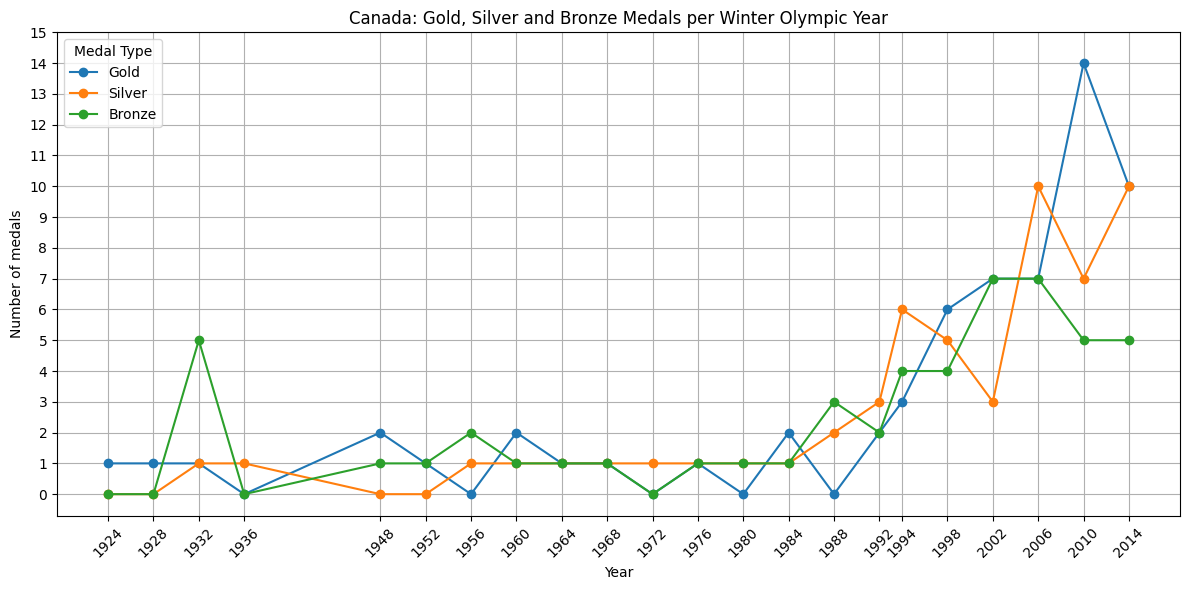

In [ ]:
#filtering medal-level dataset for Canada only
can_medals_detail = unique_medals[   #using unique medal dataset
    unique_medals["NOC"] == "CAN"    #keeping Canada only
].copy()

#grouping by year and medal type to summing counts
can_medals_by_type = (      #creating year-medal summary
    can_medals_detail
        .groupby(["Year", "Medal"])  #grouping by year and medal type
        .size()             #counting medals
        .reset_index(name="count")    #naming count column
)

#pivoting to making Gold, Silver, Bronze separate columns
can_medals_pivot = (           #reshaping for multiline plot
    can_medals_by_type
        .pivot(index="Year", columns="Medal", values="count")  #turning medal types into columns
        .fillna(0)        #replacing missing values with 0
        .sort_index()   #sorting by year
)

#creating figure
plt.figure(figsize=(12, 6))      #making figure taller

#plotting one line per medal type
for medal in ["Gold", "Silver", "Bronze"]:  #looping through medal categories

    if medal in can_medals_pivot.columns:    #checking medal exists in dataset

        plt.plot(
            can_medals_pivot.index,   #x-axis = year
            can_medals_pivot[medal],   #y-axis = medal count
            marker="o",
            label=medal
        )

#forcing every Olympic year to display
plt.xticks(
    can_medals_pivot.index,    #showing all Olympic years
    rotation=45
)

#creating more detailed y-axis ticks
max_medals = int(can_medals_pivot.max().max())  #getting max medal count across types
plt.yticks(
    np.arange(0, max_medals + 2, 1)  #creating tick every 1 medal for precision
)

#adding title and labels
plt.title("Canada: Gold, Silver and Bronze Medals per Winter Olympic Year")
plt.xlabel("Year")
plt.ylabel("Number of medals")

#adding legend and grid
plt.legend(title="Medal Type")
plt.grid(True)

#adjusting layout
plt.tight_layout()

#showing final plot
plt.show()

## **4.3 Total number of 10 highest medal count countries per year**

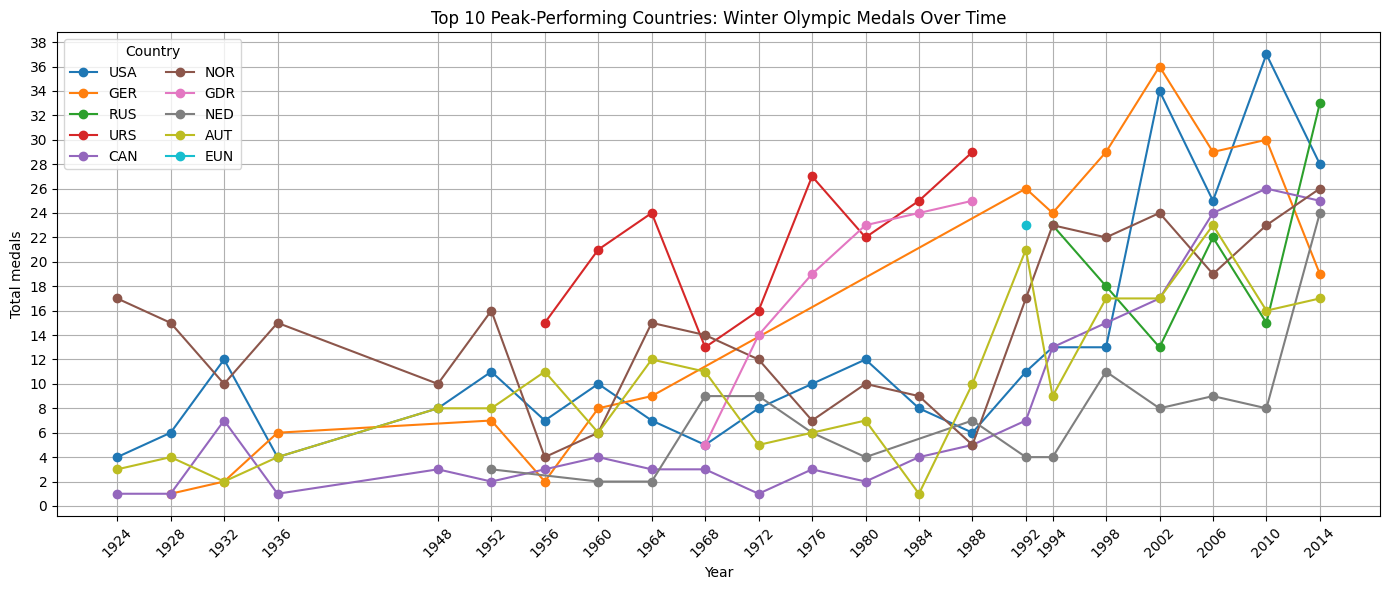

In [ ]:
#calculating each country peak medal total across all years
country_peaks = (               #building country-level peak table
    medal_counts
        .groupby("NOC")                   #grouping by country code
        ["total_medals_noc_year"]        #selecting medal total column
        .max()                             #taking max medals achieved in any year
        .reset_index(name="peak_medals")     #resetting into dataframe with clear column name
)

#selecting top 10 countries by peak medals
top10_countries = (                  #choosing top 10 countries
    country_peaks
        .nlargest(10, "peak_medals")   #keeping the 10 highest peak performers
        ["NOC"]                    #keeping only country codes
        .tolist()              #converting to list for looping
)

#filtering medal_counts to keep only those top 10 countries
top10_data = medal_counts[
    medal_counts["NOC"].isin(top10_countries)   #keeping only top 10 countries
].copy()          #creating safe copy

#collecting all years that exist in this filtered data
all_years = sorted(top10_data["Year"].unique())   #getting all years and sorting chronologically

#creating figure for multiple lines
plt.figure(figsize=(14, 6))             #widening figure to fit many ticks and lines

#looping through each country and plotting its full trend
for country in top10_countries:        #iterating through the 10 selected countries

    country_data = top10_data[
        top10_data["NOC"] == country    #filtering one country at a time
    ].sort_values("Year")               #sorting by year for clean line

    plt.plot(
        country_data["Year"],             #plotting years on x-axis
        country_data["total_medals_noc_year"],   #plotting total medals on y-axis
        marker="o",        #marking points for each Olympic year
        label=country      #labelling line in legend
    )

#forcing all years to appear on x-axis
plt.xticks(
    all_years,    #placing tick at every Olympic year available
    rotation=45           #rotating labels for readability
)

#creating more y-axis ticks (every 2 medals for more detail)
max_medals = top10_data["total_medals_noc_year"].max()  #getting max medal value for tick range
plt.yticks(
    np.arange(0, max_medals + 2, 2)    #creating ticks every 2 medals
)

#adding chart labels and title
plt.title("Top 10 Peak-Performing Countries: Winter Olympic Medals Over Time")  #setting title
plt.xlabel("Year")              #labelling x-axis
plt.ylabel("Total medals")       #labelling y-axis

#adding legend and grid
plt.legend(title="Country", ncol=2) #showing legend in 2 columns to save space
plt.grid(True)            #adding grid for easier reading

#adjusting layout
plt.tight_layout()      #preventing labels from being cut off

#showing plot
plt.show()       #rendering the chart

## **4.4 Total number of 6 highest medal winners of all times**

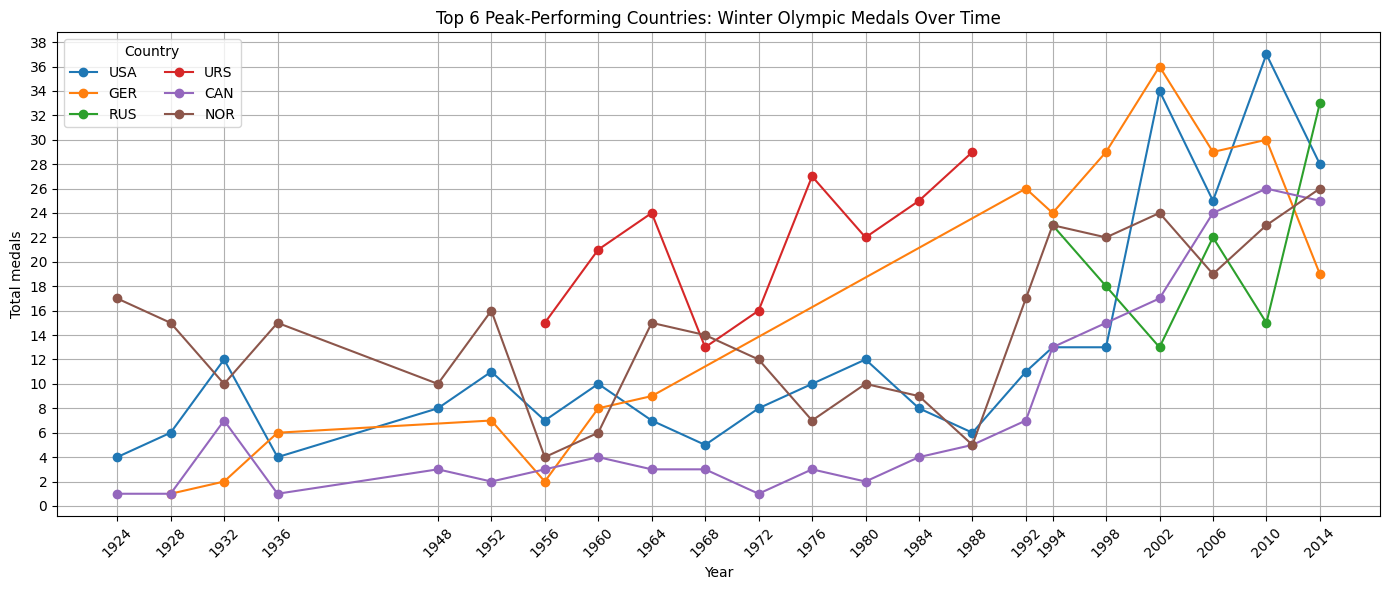

In [ ]:
#calculating each country peak medal total across all years
country_peaks = (               #building country-level peak table
    medal_counts
        .groupby("NOC")                   #grouping by country code
        ["total_medals_noc_year"]        #selecting medal total column
        .max()                             #taking max medals achieved in any year
        .reset_index(name="peak_medals")     #resetting into dataframe with clear column name
)

#selecting top 6 countries by peak medals
top6_countries = (                  #choosing top 6 countries
    country_peaks
        .nlargest(6, "peak_medals")   #keeping the 6 highest peak performers
        ["NOC"]                    #keeping only country codes
        .tolist()              #converting to list for looping
)

#filtering medal_counts to keep only those top 6 countries
top6_data = medal_counts[
    medal_counts["NOC"].isin(top6_countries)   #keeping only top 6 countries
].copy()          #creating safe copy

#collecting all years that exist in this filtered data
all_years = sorted(top6_data["Year"].unique())   #getting all years and sorting chronologically

#creating figure for multiple lines
plt.figure(figsize=(14, 6))             #widening figure to fit many ticks and lines

#looping through each country and plotting its full trend
for country in top6_countries:        #iterating through the 6 selected countries

    country_data = top6_data[
        top6_data["NOC"] == country    #filtering one country at a time
    ].sort_values("Year")               #sorting by year for clean line

    plt.plot(
        country_data["Year"],             #plotting years on x-axis
        country_data["total_medals_noc_year"],   #plotting total medals on y-axis
        marker="o",        #marking points for each Olympic year
        label=country      #labelling line in legend
    )

#forcing all years to appear on x-axis
plt.xticks(
    all_years,    #placing tick at every Olympic year available
    rotation=45           #rotating labels for readability
)

#creating more y-axis ticks (every 2 medals for more detail)
max_medals = top6_data["total_medals_noc_year"].max()  #getting max medal value for tick range
plt.yticks(
    np.arange(0, max_medals + 2, 2)    #creating ticks every 2 medals
)

#adding chart labels and title
plt.title("Top 6 Peak-Performing Countries: Winter Olympic Medals Over Time")  #setting title
plt.xlabel("Year")              #labelling x-axis
plt.ylabel("Total medals")       #labelling y-axis

#adding legend and grid
plt.legend(title="Country", ncol=2) #showing legend in 2 columns to save space
plt.grid(True)            #adding grid for easier reading

#adjusting layout
plt.tight_layout()      #preventing labels from being cut off

#showing plot
plt.show()       #rendering the chart

Separating URS and RUS preserves geopolitical accuracy but then we will have a fragmented performance analysis.

Merging them would help us in understanding the Russian competitive dominance across political transitions.

We will need to discuss if our focus is institutional sporting continuity or historical national identity. (From discussing with David, it would be better to not merge them, for political reasons, and considering the current political scenario)

Because of that, I will also investigate the entire list of names we have here, to flag for these changes and see which ones would be relevant for us to conside in this visualisation.

## **4.4 Investigating the relevance of countries that merged or split over time**

### **4.4.1 Checking all NOCs**

In [ ]:
#extracting all unique country codes from medal_counts
all_countries = (     #creating sorted list of NOC codes
    medal_counts["NOC"]      #selecting NOC column
        .unique()          #getting unique values only
)

#sorting alphabetically for easier inspection
all_countries = sorted(all_countries)  #sorting country codes A to Z

#printing total number of countries
print("Total number of countries:", len(all_countries))  #showing how many NOCs exist

#displaying full list
print(all_countries)      #printing all NOC codes clearly

Total number of countries: 46
['AUS', 'AUT', 'BEL', 'BLR', 'BUL', 'CAN', 'CHN', 'CRO', 'CZE', 'DEN', 'ESP', 'EST', 'EUN', 'FIN', 'FRA', 'FRG', 'GBR', 'GDR', 'GER', 'HUN', 'IND', 'ITA', 'JPN', 'KAZ', 'KOR', 'LAT', 'LIE', 'LUX', 'NED', 'NEP', 'NOR', 'NZL', 'POL', 'PRK', 'ROU', 'RUS', 'SLO', 'SUI', 'SVK', 'SWE', 'TCH', 'UKR', 'URS', 'USA', 'UZB', 'YUG']


In [ ]:
#creating dataframe for cleaner viewing
countries_df = pd.DataFrame(all_countries, columns=["NOC"])  #turning list into dataframe

display(countries_df)  #showing scrollable table

,NOC
0,AUS
1,AUT
2,BEL
3,BLR
4,BUL
5,CAN
6,CHN
7,CRO
8,CZE
9,DEN


### **4.4.2 Countries changes over time**

#### Successor-State Transitions Present in This Dataset

## Soviet Union: Russia and other independent states (1991)

- `URS` (Soviet Union) competed until 1988.
- The Soviet Union dissolved in 1991.
- `EUN` (Unified Team) competed in 1992, representing former Soviet republics during transition.
- From 1994 onward, independent states competed separately (`RUS`, `UKR`, `BLR`, `KAZ`, `LAT`, `EST`, `UZB`).
- For performance continuity analysis, `URS` and `EUN` are often merged into `RUS`.



## East Germany + West Germany: Germany (1990)

- `FRG` (West Germany) competed from 1949 to 1990.
- `GDR` (East Germany) competed from 1968 to 1988.
- Germany reunified in 1990.
- From 1992 onward, `GER` represents unified Germany.
- For continuity analysis, `GDR` and `FRG` are merged into `GER`.



## Czechoslovakia: Czech Republic + Slovakia (1993)

- `TCH` (Czechoslovakia) competed until 1992.
- The country split peacefully in 1993.
- From 1994 onward, `CZE` and `SVK` competed separately.
- For longitudinal sporting analysis, `TCH` is sometimes merged into `CZE`, though this is a methodological choice.



## Yugoslavia: Multiple successor states (1991–1992)

- `YUG` competed until the early 1990s.
- Yugoslavia dissolved beginning in 1991.
- Successor states include `CRO` (Croatia), `SLO` (Slovenia), `SRB` (Serbia), and others.
- Merging is analytically complex because performance legacy is distributed across multiple successor nations.



## Countries with Continuous Olympic Identity

The following countries did not undergo structural political splits during the period observed and maintained consistent NOC representation:

`USA`, `CAN`, `NOR`, `SWE`, `FIN`, `FRA`, `ITA`, `JPN`, `AUT`, `SUI`, `NED`, which ones are we missing here?


## Sources:
https://history.state.gov/milestones/1989-1992/collapse-soviet-union

https://www.olympedia.org/countries/EUN

https://www.britannica.com/topic/German-reunification

https://www.olympedia.org/countries/FRG

https://www.olympedia.org/countries/GDR

https://www.olympedia.org/countries/GER

https://www.britannica.com/topic/Velvet-Divorce

https://www.olympedia.org/countries/TCH

https://www.olympedia.org/countries/CZE

https://www.olympedia.org/countries/SVK

https://www.britannica.com/place/Yugoslavia-former-federated-nation-1929-2003




# **5. Manual Predictions**

Building a manual forecasting model to estimate Canada's Winter Olympic medal performance.

Instead of evaluating predictive accuracy on past winter olympics medals count, our goal is to have a projection to the future. Because fo this, we will include the recent era data (1994 to 2022) to estimate the trend in medal performance and project the expected number of medals for the 2026 Winter Olympics.

We selected dates from 1994 onwards, because the visual trend shows a structural change in Canada's performance from the 90s, which was a reflection of probably more funding, athlete development programs, and competitive positioning.


##**5.1 Total number of medals CAN**

### **5.1.1 Filtering for canada only**

We isolate Canada's medal totals from the full dataset. The data is sorted chronologically (time consistency) before building the regression model


In [ ]:
#filtering canada medal totals
can_medals = medal_counts[
    medal_counts["NOC"] == "CAN"  #keeping Canada only
].copy()

#sorting by year to keep timeline consistent
can_medals = can_medals.sort_values("Year").reset_index(drop=True)

#keeping only modern era to avoid mixing very different historical periods
can_modern = can_medals[
    can_medals["Year"] >= 1994  #starting when the trend structurally changes in your plot
].copy()

#double-checking what we have
print("Modern era rows:", can_modern.shape[0])
display(can_modern[["Year", "total_medals_noc_year"]])

Modern era rows: 6


,Year,total_medals_noc_year
16,1994,13
17,1998,15
18,2002,17
19,2006,24
20,2010,26
21,2014,25


### **5.1.2 building manual simple linear regression**

We use a simple linear regression model with year as the independent variable and total medals as the dependent variable.

The slope of the regression is the average increase in medals per year. Multiplying this value by four provides an estimate of the average medal increase per Olympic cycle.


In [ ]:
#creating X and y for regression
X = can_modern[["Year"]].values  #keeping as 2D array for sklearn
y = can_modern["total_medals_noc_year"].values

#creating and fitting the regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)

#extracting regression parameters for interpretation
slope = float(lin_reg.coef_[0])       #getting medals per year
intercept = float(lin_reg.intercept_) #getting baseline intercept

print(f"Slope (medals per year): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

#converting slope to medals per Olympic cycle (4 years)
print(f"Approx medals per Olympic cycle: {slope * 4:.2f}")

Slope (medals per year): 0.7143
Intercept: -1411.4286
Approx medals per Olympic cycle: 2.86


### **5.1.3 generating predictions (including next olympics)**

Using the fitted regression model, we generate predictions for 2018, 2022, and 2026.

2018 and 2022 are already known, but we included them here for consistency within the forecasting framework. The primary focus is the projection for 2026.


In [ ]:
#generating predictions for 2018, 2022, 2026 and comparing where actual exists

pred_years = np.array([2018, 2022, 2026]).reshape(-1, 1)
pred_vals = lin_reg.predict(pred_years)

actual_lookup = can_modern.set_index("Year")["total_medals_noc_year"].to_dict()

for year, pred in zip(pred_years.flatten(), pred_vals):
    if year in actual_lookup:
        actual = actual_lookup[year]
        print(f"{year} -> Actual: {actual} | Predicted: {pred:.2f} | Error: {pred - actual:+.2f}")
    else:
        print(f"{year} -> Predicted: {pred:.2f}")

2018 -> Predicted: 30.00
2022 -> Predicted: 32.86
2026 -> Predicted: 35.71


### **5.1.4 evaluating fit quality**

To understand how well the linear model gets historical trends, we calculate the Mean Absolute Error (MAE) and the coefficient of determination (R2).

MAE indicates the average prediction error in medal counts, and R2 shows how much variance in medal totals is explained by the linear trend.


In [ ]:
#in-sample predictions
y_pred = lin_reg.predict(X)

mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error (MAE): 1.48
R² Score: 0.893


### **5.1.5 plotting actual vs regression line**

here, we visualize the historical medal counts alongside the fitted regression line.

This allows us to observe if performance is accelerating, stabilising, or plateauing in comparison with the linear trend.


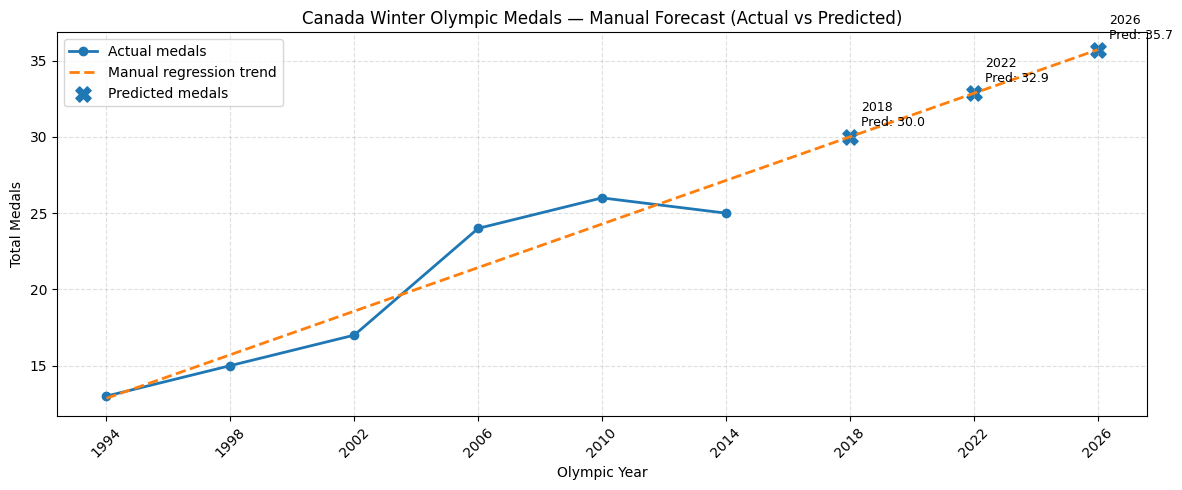

In [ ]:
#creating olympic-year axis (every 4 years)
year_min = int(can_modern["Year"].min())
year_max = 2026
olympic_years = np.arange(year_min, year_max + 1, 4)

#predicting regression line on olympic years only
reg_line = lin_reg.predict(olympic_years.reshape(-1, 1))

#predicting key years
pred_years = np.array([2018, 2022, 2026]).reshape(-1, 1)
pred_vals = lin_reg.predict(pred_years)

#building lookup for actual values (when available)
actual_lookup = can_modern.set_index("Year")["total_medals_noc_year"].to_dict()

plt.figure(figsize=(12, 5))

#actual medals
plt.plot(
    can_modern["Year"],
    can_modern["total_medals_noc_year"],
    marker="o",
    linewidth=2,
    label="Actual medals"
)

#manual regression trend (dashed)
plt.plot(
    olympic_years,
    reg_line,
    linestyle="--",
    linewidth=2,
    label="Manual regression trend"
)

#predicted points (2018, 2022, 2026)
plt.scatter(
    pred_years.flatten(),
    pred_vals,
    marker="X",
    s=120,
    label="Predicted medals"
)

#annotating predicted vs actual for 2018 and 2022, and prediction for 2026
for year, pred in zip(pred_years.flatten(), pred_vals):
    if year in actual_lookup:
        actual = actual_lookup[year]
        label = f"{year}\nActual: {actual}\nPred: {pred:.1f}"
    else:
        label = f"{year}\nPred: {pred:.1f}"

    plt.annotate(
        label,
        (year, pred),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9
    )

#formatting x-axis to show only olympic years
plt.xticks(olympic_years, rotation=45)

plt.title("Canada Winter Olympic Medals — Manual Forecast (Actual vs Predicted)")
plt.xlabel("Olympic Year")
plt.ylabel("Total Medals")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

manual regression model was trained using only data from 1994 to 2014

ANd then, we used it to project 2018, 2022, and 2026.

##**5.2 Gold, Silver and Bronze medals CAN**

### **5.2.1 can medal counts per medal type**

In [ ]:
#1.preparing the pivot table as a clean dataframe

#making sure medal columns exist even if some years have zero
for medal in ["Gold", "Silver", "Bronze"]:
    if medal not in can_medals_pivot.columns:
        can_medals_pivot[medal] = 0

#converting pivot table to a standard dataframe
can_medals_df = can_medals_pivot.reset_index().copy()

#keeping modern era only (same logic as you used)
can_medals_df = can_medals_df[can_medals_df["Year"] >= 1994].copy()

#keeping only Olympic years
can_medals_df = can_medals_df[can_medals_df["Year"] % 4 == 2].copy()

#sorting chronologically
can_medals_df = can_medals_df.sort_values("Year").reset_index(drop=True)

display(can_medals_df)


#2.training window + prediction years

train_df = can_medals_df[can_medals_df["Year"] <= 2014].copy()

pred_years = np.array([2018, 2022, 2026]).reshape(-1, 1)

#medal colors (explicit)
medal_specs = {
    "Gold":   {"label": "Gold",   "color": "#D4AF37"},
    "Silver": {"label": "Silver", "color": "#C0C0C0"},
    "Bronze": {"label": "Bronze", "color": "#CD7F32"},
}

#building olympic-year axis for the trend lines
year_min = int(can_medals_df["Year"].min())
year_max = 2026
olympic_years = np.arange(year_min, year_max + 1, 4).reshape(-1, 1)

#lookup for actual values (for labels)
actual_lookup = can_medals_df.set_index("Year")[["Gold", "Silver", "Bronze"]].to_dict("index")

Medal,Year,Bronze,Gold,Silver
0,1994,4.0,3.0,6.0
1,1998,4.0,6.0,5.0
2,2002,7.0,7.0,3.0
3,2006,7.0,7.0,10.0
4,2010,5.0,14.0,7.0
5,2014,5.0,10.0,10.0


### **5.2.2 plotting regression**

so what did you do fpr eda

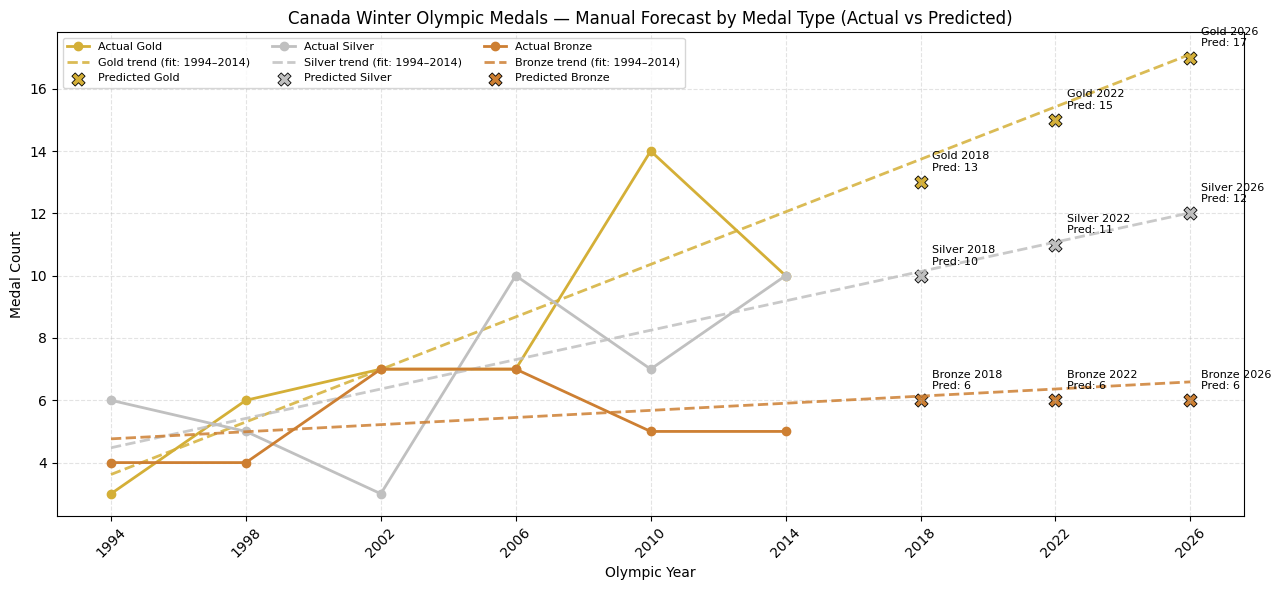

In [ ]:
plt.figure(figsize=(13, 6))

for medal, spec in medal_specs.items():
    #training regression for this medal type
    X_train = train_df[["Year"]].values
    y_train = train_df[medal].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    #trend line predictions (Olympic years only)
    trend_vals = model.predict(olympic_years)

    #forecast points
    pred_vals = model.predict(pred_years)

    #ensuring predictions are realistic medal counts
    pred_vals = np.floor(np.maximum(pred_vals, 0)).astype(int)

    #actual line
    plt.plot(
        can_medals_df["Year"],
        can_medals_df[medal],
        marker="o",
        linewidth=2,
        color=spec["color"],
        label=f"Actual {spec['label']}"
    )

    #dashed trend line
    plt.plot(
        olympic_years.flatten(),
        trend_vals,
        linestyle="--",
        linewidth=2,
        color=spec["color"],
        alpha=0.85,
        label=f"{spec['label']} trend (fit: 1994–2014)"
    )

    #predicted points
    plt.scatter(
        pred_years.flatten(),
        pred_vals,
        marker="X",
        s=90,
        color=spec["color"],
        edgecolor="black",
        linewidth=0.6,
        label=f"Predicted {spec['label']}"
    )

    #annotations (actual vs predicted for 2018 and 2022, predicted only for 2026)
    for year, pred in zip(pred_years.flatten(), pred_vals):
        if year in actual_lookup:
            actual = actual_lookup[year][medal]
            label = f"{spec['label']} {year}\nActual: {actual} | Pred: {pred}"
        else:
            label = f"{spec['label']} {year}\nPred: {pred}"

        plt.annotate(
            label,
            (year, pred),
            textcoords="offset points",
            xytext=(8, 8),
            fontsize=8
        )

#axis formatting
plt.xticks(np.arange(year_min, year_max + 1, 4), rotation=45)
plt.title("Canada Winter Olympic Medals — Manual Forecast by Medal Type (Actual vs Predicted)")
plt.xlabel("Olympic Year")
plt.ylabel("Medal Count")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# **6. Linear regression predictions (Ice Hockey)**

## 6.1 filtering out the events (only Ice Hockey)

In [ ]:
#Looking at ath_winter to see what features we have so we can filter and train/predict on nessacerry features
display(ath_winter)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year
0,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No_Medal,10,11,6,5,7
1,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,10,11,6,5,7
2,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No_Medal,13,19,9,10,4
3,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No_Medal,13,19,9,10,4
4,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No_Medal,17,21,13,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48559,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,No_Medal,25,56,43,13,0
48560,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",No_Medal,58,58,35,23,6
48561,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",No_Medal,58,58,35,23,6
48562,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,No_Medal,35,39,24,15,0


In [ ]:
ath_winter["Sport"].unique()

array(['Speed Skating', 'Cross Country Skiing', 'Ice Hockey', 'Biathlon',
       'Alpine Skiing', 'Luge', 'Bobsleigh', 'Figure Skating',
       'Nordic Combined', 'Freestyle Skiing', 'Ski Jumping', 'Curling',
       'Snowboarding', 'Short Track Speed Skating', 'Skeleton',
       'Military Ski Patrol', 'Alpinism'], dtype=object)

In [ ]:
#filter out ice hockey by filtering the event column and extracting the ones with Ice hockey keyword
ice_hockey_df = ath_winter[ath_winter["Sport"]== "Ice Hockey"]
ice_hockey_df.reset_index(inplace=True, drop=True)
display(ice_hockey_df)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year
0,9,Antti Sami Aalto,M,26.0,186.0,96.0,Finland,FIN,2002 Winter,2002,Winter,Salt Lake City,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,41,98,62,36,7
1,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,41,99,66,33,5
2,391,Clarence John Abel,M,23.0,185.0,102.0,United States,USA,1924 Winter,1924,Winter,Chamonix,Ice Hockey,Ice Hockey Men's Ice Hockey,Silver,11,24,22,2,4
3,392,George Gordon Abel,M,35.0,NaN,NaN,Canada,CAN,1952 Winter,1952,Winter,Oslo,Ice Hockey,Ice Hockey Men's Ice Hockey,Gold,16,39,31,8,2
4,523,Trond Sevg Abrahamsen,M,19.0,183.0,87.0,Norway,NOR,1980 Winter,1980,Winter,Lake Placid,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,28,63,54,9,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5451,135460,Andrzej Jerzy urawski,M,23.0,176.0,75.0,Poland,POL,1964 Winter,1964,Winter,Innsbruck,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,24,51,40,11,0
5452,135469,Karol urek,M,27.0,177.0,76.0,Poland,POL,1976 Winter,1976,Winter,Innsbruck,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,25,56,43,13,0
5453,135483,Andrey Aleksandrovich Zuyev,M,29.0,NaN,NaN,Russia,RUS,1994 Winter,1994,Winter,Lillehammer,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,56,113,75,38,23
5454,135538,Jonathan Zwikel,M,22.0,183.0,84.0,France,FRA,1998 Winter,1998,Winter,Nagano,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,47,106,75,31,8


## 6.2 predicting number of medals for Ice hockey only

Processed Canadian Ice Hockey Medal Counts (1994 onwards):


,Year,total_ice_hockey_medals_noc_year
0,1994,1
1,1998,1
2,2002,2
3,2006,1
4,2010,2
5,2014,2


Shape: (6, 2)

Ice Hockey Slope (medals per year): 0.0500
Ice Hockey Intercept: -98.7000

Ice Hockey Medal Predictions:
2018 -> Predicted: 2
2022 -> Predicted: 2
2026 -> Predicted: 2

Ice Hockey Mean Absolute Error (MAE): 0.27
Ice Hockey R² Score: 0.467


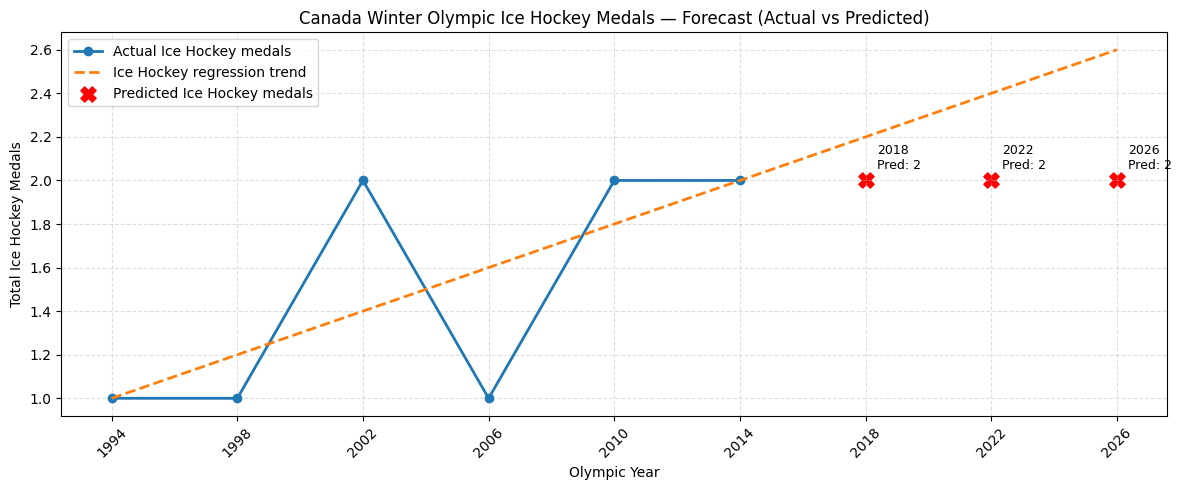

In [ ]:
# 1. Prepare Ice Hockey Medal Data

# Filter for Canadian Ice Hockey medals only
can_ice_hockey_medals_only = ice_hockey_df[
    (ice_hockey_df["NOC"] == "CAN") &
    (ice_hockey_df["Medal"].isin(["Gold", "Silver", "Bronze"]))].copy()

# Remove duplicate entries for team medals
can_unique_ice_hockey_medals = can_ice_hockey_medals_only.drop_duplicates(
    subset=['Event', 'NOC', 'Year', 'Medal']
).copy()

# Group by 'Year' and count the number of medals for each year
can_ice_hockey_medal_counts = (
    can_unique_ice_hockey_medals
    .groupby('Year')
    .size()
    .reset_index(name='total_ice_hockey_medals_noc_year')
)

# Filter for modern era (1994 onwards)
can_ice_hockey_medal_counts = can_ice_hockey_medal_counts[
    can_ice_hockey_medal_counts['Year'] >= 1994
].copy()

# Sort by 'Year' and reset index
can_ice_hockey_medal_counts = can_ice_hockey_medal_counts.sort_values('Year').reset_index(drop=True)

print("Processed Canadian Ice Hockey Medal Counts (1994 onwards):")
display(can_ice_hockey_medal_counts)
print(f"Shape: {can_ice_hockey_medal_counts.shape}")

# 2. Build Ice Hockey Regression Model

X_ice_hockey = can_ice_hockey_medal_counts[['Year']].values
y_ice_hockey = can_ice_hockey_medal_counts['total_ice_hockey_medals_noc_year'].values

lin_reg_ice_hockey = LinearRegression()
lin_reg_ice_hockey.fit(X_ice_hockey, y_ice_hockey)

slope_ice_hockey = float(lin_reg_ice_hockey.coef_[0])
intercept_ice_hockey = float(lin_reg_ice_hockey.intercept_)

print(f"\nIce Hockey Slope (medals per year): {slope_ice_hockey:.4f}")
print(f"Ice Hockey Intercept: {intercept_ice_hockey:.4f}")

# 3. Predict Ice Hockey Medals for 2026

pred_years_ice_hockey = np.array([2018, 2022, 2026]).reshape(-1, 1)
pred_vals_ice_hockey = lin_reg_ice_hockey.predict(pred_years_ice_hockey)

# Ensure predictions are non-negative and integer
pred_vals_ice_hockey = np.floor(np.maximum(pred_vals_ice_hockey, 0)).astype(int)

actual_ice_hockey_lookup = can_ice_hockey_medal_counts.set_index('Year')['total_ice_hockey_medals_noc_year'].to_dict()

print("\nIce Hockey Medal Predictions:")
for year, pred in zip(pred_years_ice_hockey.flatten(), pred_vals_ice_hockey):
    if year in actual_ice_hockey_lookup:
        actual = actual_ice_hockey_lookup[year]
        print(f"{year} -> Actual: {actual} | Predicted: {pred} | Error: {pred - actual:+d}")
    else:
        print(f"{year} -> Predicted: {pred}")

# 4. Evaluate Ice Hockey Model Performance

y_pred_ice_hockey = lin_reg_ice_hockey.predict(X_ice_hockey)

mae_ice_hockey = mean_absolute_error(y_ice_hockey, y_pred_ice_hockey)
r2_ice_hockey = r2_score(y_ice_hockey, y_pred_ice_hockey)

print(f"\nIce Hockey Mean Absolute Error (MAE): {mae_ice_hockey:.2f}")
print(f"Ice Hockey R² Score: {r2_ice_hockey:.3f}")

# 5. Visualize Ice Hockey Medal Predictions

plt.figure(figsize=(12, 5))

# Creating olympic-year axis for the trend line
year_min_ice_hockey = int(can_ice_hockey_medal_counts['Year'].min())
year_max_ice_hockey = 2026
olympic_years_ice_hockey = np.arange(year_min_ice_hockey, year_max_ice_hockey + 1, 4)

# Predicting regression line on olympic years only
reg_line_ice_hockey = lin_reg_ice_hockey.predict(olympic_years_ice_hockey.reshape(-1, 1))

# Actual medals
plt.plot(
    can_ice_hockey_medal_counts['Year'],
    can_ice_hockey_medal_counts['total_ice_hockey_medals_noc_year'],
    marker='o',
    linewidth=2,
    label='Actual Ice Hockey medals'
)

# Manual regression trend (dashed)
plt.plot(
    olympic_years_ice_hockey,
    reg_line_ice_hockey,
    linestyle='--',
    linewidth=2,
    label='Ice Hockey regression trend'
)

# Predicted points (2018, 2022, 2026)
plt.scatter(
    pred_years_ice_hockey.flatten(),
    pred_vals_ice_hockey,
    marker='X',
    s=120,
    color='red',
    label='Predicted Ice Hockey medals'
)

# Annotating predicted vs actual for 2018 and 2022, and prediction for 2026
for year, pred in zip(pred_years_ice_hockey.flatten(), pred_vals_ice_hockey):
    if year in actual_ice_hockey_lookup:
        actual = actual_ice_hockey_lookup[year]
        label = f"{year}\nActual: {actual}\nPred: {pred}"
    else:
        label = f"{year}\nPred: {pred}"

    plt.annotate(
        label,
        (year, pred),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9
    )

# Formatting x-axis to show only olympic years
plt.xticks(olympic_years_ice_hockey, rotation=45)

plt.title("Canada Winter Olympic Ice Hockey Medals — Forecast (Actual vs Predicted)")
plt.xlabel("Olympic Year")
plt.ylabel("Total Ice Hockey Medals")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## 6.3 Predicting if Canada will win Gold, Silevr or Bronze

In [ ]:
# read the dataset and show head
df = pd.read_csv('df_merged_clean.csv')
df.head()

,edition,edition_id,year,country,country_noc,gold,silver,bronze,total,Games,City,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year,host_noc,is_host,is_host_int
0,1924 Winter Olympics,29,1924,Norway,NOR,4,7,6,17,1924 Winter,Chamonix,10.0,14.0,13.0,1.0,17.0,FRA,False,0
1,1924 Winter Olympics,29,1924,Belgium,BEL,0,0,1,1,1924 Winter,Chamonix,8.0,18.0,17.0,1.0,1.0,FRA,False,0
2,1924 Winter Olympics,29,1924,France,FRA,0,0,3,3,1924 Winter,Chamonix,16.0,43.0,41.0,2.0,3.0,FRA,True,1
3,1924 Winter Olympics,29,1924,Canada,CAN,1,0,0,1,1924 Winter,Chamonix,8.0,12.0,11.0,1.0,1.0,FRA,False,0
4,1924 Winter Olympics,29,1924,Sweden,SWE,1,1,0,2,1924 Winter,Chamonix,11.0,31.0,31.0,0.0,2.0,FRA,False,0


### 6.3.1 steps to be taken
To address the classification objective for Canadian Men's Ice Hockey, I will first filter the data to include only relevant events. Then, I will aggregate this data to the Olympic year level, creating `medal_binary` (medal vs. no medal) and `medal_type` (Gold, Silver, Bronze, or No_Medal) as target variables. Finally, I will incorporate the 'is_host' feature and the unique athlete count specific to Men's Ice Hockey from the existing dataframes.

The following code will perform these steps:
1.  Filter the `ath_winter` DataFrame for Canadian Men's Ice Hockey events.
2.  Aggregate the filtered data by 'Year' to determine the medal outcome for each Olympic year.
3.  Create the `medal_binary` and `medal_type` target variables.
4.  Extract the `is_host` information for Canada from the `df` DataFrame (which was loaded from `df_merged_clean.csv`) and merge it.
5.  Calculate the number of unique Men's Ice Hockey athletes for Canada per year and add it as a feature.

### 6.3.2 Prepare Men's Ice Hockey Data for Classification

Filter the dataset to include only Canadian Men's Ice Hockey events, aggregate to an Olympic year level, and create `medal_binary` and `medal_type` target variables. Incorporate the 'is_host' feature and identify other available features from the current context, noting limitations for external data.


**Reasoning**:
The first step is to filter the `ath_winter` DataFrame to isolate Canadian Men's Ice Hockey events. This is done by filtering on 'NOC', 'Sport', and 'Event' columns as specified in the instructions. This prepares the data for subsequent aggregation and feature engineering.



In [ ]:
can_men_ice_hockey = ath_winter[
    (ath_winter['NOC'] == 'CAN') &
    (ath_winter['Sport'] == 'Ice Hockey') &
    (ath_winter['Event'] == "Ice Hockey Men's Ice Hockey")
].copy()

display(can_men_ice_hockey.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,unique_event_count,unique_athlete_count,unique_male_count,unique_female_count,total_medals_noc_year
79,392,George Gordon Abel,M,35.0,NaN,NaN,Canada,CAN,1952 Winter,1952,Winter,Oslo,Ice Hockey,Ice Hockey Men's Ice Hockey,Gold,16,39,31,8,2
381,1627,"Henry ""Hank"" Akervall",M,26.0,NaN,NaN,Canada,CAN,1964 Winter,1964,Winter,Innsbruck,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,27,55,43,12,3
832,3819,Glenn Christopher Anderson,M,19.0,185.0,86.0,Canada,CAN,1980 Winter,1980,Winter,Lake Placid,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,26,59,41,18,2
848,3867,Warren Anderson,M,27.0,177.0,82.0,Canada,CAN,1980 Winter,1980,Winter,Lake Placid,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,26,59,41,18,2
849,3867,Warren Anderson,M,31.0,177.0,82.0,Canada,CAN,1984 Winter,1984,Winter,Sarajevo,Ice Hockey,Ice Hockey Men's Ice Hockey,No_Medal,30,67,47,20,4


**Reasoning**:
The next step is to aggregate the filtered Canadian Men's Ice Hockey data by year to determine the medal outcome. This involves checking for 'Gold', 'Silver', or 'Bronze' medals to set the 'medal_binary' and 'medal_type' for each Olympic year.



In [ ]:
can_men_ice_hockey_agg = can_men_ice_hockey.groupby('Year').agg(
    medals_won=('Medal', lambda x: x[x.isin(['Gold', 'Silver', 'Bronze'])].unique().tolist())
).reset_index()

# Determine medal_type and medal_binary
def get_medal_info(medals_list):
    if 'Gold' in medals_list:
        return 'Gold', 1
    elif 'Silver' in medals_list:
        return 'Silver', 1
    elif 'Bronze' in medals_list:
        return 'Bronze', 1
    else:
        return 'No_Medal', 0

can_men_ice_hockey_agg[['medal_type', 'medal_binary']] = can_men_ice_hockey_agg['medals_won'].apply(lambda x: pd.Series(get_medal_info(x)))

# Drop the intermediate 'medals_won' column
can_men_ice_hockey_agg = can_men_ice_hockey_agg.drop(columns=['medals_won'])

display(can_men_ice_hockey_agg.head())


,Year,medal_type,medal_binary
0,1924,Gold,1
1,1928,Gold,1
2,1932,Gold,1
3,1936,Silver,1
4,1948,Gold,1


**Reasoning**:
To incorporate the 'is_host' feature, I will extract the 'Year' and 'is_host' columns for Canada from the `df` DataFrame and then merge this information into the `can_men_ice_hockey_agg` DataFrame. This will add context on whether Canada was the host nation in a given year.



In [ ]:
can_host_info = df[(df['country_noc'] == 'CAN')][['year', 'is_host']].drop_duplicates().rename(columns={'year': 'Year'}) # Extract host info and rename 'year' to 'Year' for merging

can_men_ice_hockey_agg = can_men_ice_hockey_agg.merge(can_host_info, on='Year', how='left')

# Fill NaN values in 'is_host' with False (assuming if not explicitly marked, they were not host)
can_men_ice_hockey_agg['is_host'] = can_men_ice_hockey_agg['is_host'].fillna(False)

display(can_men_ice_hockey_agg.head())

,Year,medal_type,medal_binary,is_host
0,1924,Gold,1,False
1,1928,Gold,1,False
2,1932,Gold,1,False
3,1936,Silver,1,False
4,1948,Gold,1,False


**Reasoning**:
To fulfill the last instruction, I will calculate the number of unique male athletes who participated in Canadian Men's Ice Hockey for each Olympic year using the `can_men_ice_hockey` DataFrame, and then merge this count into the `can_men_ice_hockey_agg` DataFrame as a new feature.



In [ ]:
unique_men_ice_hockey_athletes = can_men_ice_hockey.groupby('Year')['ID'].nunique().reset_index(name='unique_male_ice_hockey_athletes')

can_men_ice_hockey_agg = can_men_ice_hockey_agg.merge(unique_men_ice_hockey_athletes, on='Year', how='left')

# Ensure the count is integer and fill any potential NaN (shouldn't happen with left merge here if years align) with 0
can_men_ice_hockey_agg['unique_male_ice_hockey_athletes'] = can_men_ice_hockey_agg['unique_male_ice_hockey_athletes'].fillna(0).astype(int)

display(can_men_ice_hockey_agg.head())

,Year,medal_type,medal_binary,is_host,unique_male_ice_hockey_athletes
0,1924,Gold,1,False,9
1,1928,Gold,1,False,12
2,1932,Gold,1,False,14
3,1936,Silver,1,False,13
4,1948,Gold,1,False,12


### 6.3.3 Feature Engineering for Classification

Create 'Previous Olympic result' (lag) feature for medal_binary and medal_type. Identify and note other requested features that require external data.


**Reasoning**:
The first step is to sort the DataFrame by 'Year' to ensure that the lag features are calculated correctly, reflecting the previous Olympic year's results.



In [ ]:
can_men_ice_hockey_agg = can_men_ice_hockey_agg.sort_values('Year').reset_index(drop=True)

display(can_men_ice_hockey_agg.head())

,Year,medal_type,medal_binary,is_host,unique_male_ice_hockey_athletes
0,1924,Gold,1,False,9
1,1928,Gold,1,False,12
2,1932,Gold,1,False,14
3,1936,Silver,1,False,13
4,1948,Gold,1,False,12


**Reasoning**:
Now that the DataFrame is sorted by year, I will create the `previous_medal_binary` and `previous_medal_type` lag features by shifting the respective columns. Then, I will handle the NaN values introduced by the shift operation, filling `previous_medal_binary` with 0 and `previous_medal_type` with 'No_Previous_Record', and convert `previous_medal_binary` to an integer.



In [ ]:
can_men_ice_hockey_agg['previous_medal_binary'] = can_men_ice_hockey_agg['medal_binary'].shift(1).fillna(0).astype(int)
can_men_ice_hockey_agg['previous_medal_type'] = can_men_ice_hockey_agg['medal_type'].shift(1).fillna('No_Previous_Record')

display(can_men_ice_hockey_agg.head())

,Year,medal_type,medal_binary,is_host,unique_male_ice_hockey_athletes,previous_medal_binary,previous_medal_type
0,1924,Gold,1,False,9,0,No_Previous_Record
1,1928,Gold,1,False,12,1,Gold
2,1932,Gold,1,False,14,1,Gold
3,1936,Silver,1,False,13,1,Gold
4,1948,Gold,1,False,12,1,Silver


### Feature Review and Identification of Additional Features

**Current Features in `can_men_ice_hockey_agg`:**
- `Year`: The Olympic year.
- `medal_type`: The type of medal won (Gold, Silver, Bronze, No_Medal).
- `medal_binary`: Binary indicator for winning any medal (1) or no medal (0).
- `is_host`: Boolean indicator if Canada was the host nation in that year.
- `unique_male_ice_hockey_athletes`: Number of unique male athletes in Canadian Ice Hockey for that year.
- `previous_medal_binary`: Medal outcome (binary) from the previous Olympic year.
- `previous_medal_type`: Medal type from the previous Olympic year.

**Additional Potentially Useful Features:**

### Features Requiring Aggregation from `ath_winter` (Internal Data):
- **Average Age of Team:** The average age of Canadian Men's Ice Hockey athletes for each Olympic year. This could indicate team experience or youth movement.
- **Average Height/Weight of Team:** The average physical attributes of the Canadian Men's Ice Hockey team. While less direct, these might be proxies for physical dominance or playing style.
- **Number of unique female ice hockey athletes:** Although the target is men's ice hockey, the overall health of the national ice hockey program (including women's participation and success) might indirectly influence the men's team's performance, reflecting broader program support or talent development.

### Features Requiring External Data Sources:
- **Team World Ranking/Performance in Non-Olympic Tournaments:** Data from IIHF World Championships, World Cups, or other major international tournaments in the years leading up to the Olympics. This would provide a more continuous measure of team strength.
- **Coaching Staff Changes:** Information on head coach changes or key coaching staff appointments, as these can significantly impact team strategy and morale.
- **National Sports Funding for Ice Hockey:** Government or private funding allocated to Ice Hockey Canada in the years prior to each Olympics. Increased investment often correlates with better performance.
- **Player Availability/Injuries:** Information on star players missing due to injury or other commitments (e.g., NHL playoff conflicts).
- **International Competition Form (e.g., World Championships):** Recent performance against top teams in other major competitions could be a strong predictor.
- **Economic Indicators:** National economic stability or growth could indirectly influence sports funding and athlete support.

These external features would require significant data collection and integration beyond the scope of the provided datasets.

### 6.3.4 Data Preprocessing for Classification

### Subtask:
Handle any missing values, encode categorical variables (like `is_host` and `previous_medal_type`), and prepare for class imbalance considerations.


**Reasoning**:
To prepare the 'is_host' feature for modeling, I will convert the boolean values to integers (0 or 1) as instructed.



In [ ]:
can_men_ice_hockey_agg['is_host'] = can_men_ice_hockey_agg['is_host'].astype(int)

display(can_men_ice_hockey_agg.head())

,Year,medal_type,medal_binary,is_host,unique_male_ice_hockey_athletes,previous_medal_binary,previous_medal_type
0,1924,Gold,1,0,9,0,No_Previous_Record
1,1928,Gold,1,0,12,1,Gold
2,1932,Gold,1,0,14,1,Gold
3,1936,Silver,1,0,13,1,Gold
4,1948,Gold,1,0,12,1,Silver


**Reasoning**:
To encode the categorical 'previous_medal_type' column into numerical format for modeling, I will apply one-hot encoding. This will create new binary columns for each medal type, prefixed as requested, and the original column will be dropped to prevent multicollinearity.



In [ ]:
can_men_ice_hockey_agg = pd.get_dummies(can_men_ice_hockey_agg, columns=['previous_medal_type'], prefix='prev_medal_type')

display(can_men_ice_hockey_agg.head())
can_men_ice_hockey_agg.info()

,Year,medal_type,medal_binary,is_host,unique_male_ice_hockey_athletes,previous_medal_binary,prev_medal_type_Bronze,prev_medal_type_Gold,prev_medal_type_No_Medal,prev_medal_type_No_Previous_Record,prev_medal_type_Silver
0,1924,Gold,1,0,9,0,False,False,False,True,False
1,1928,Gold,1,0,12,1,False,True,False,False,False
2,1932,Gold,1,0,14,1,False,True,False,False,False
3,1936,Silver,1,0,13,1,False,True,False,False,False
4,1948,Gold,1,0,12,1,False,False,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Year                                20 non-null     int64 
 1   medal_type                          20 non-null     object
 2   medal_binary                        20 non-null     int64 
 3   is_host                             20 non-null     int64 
 4   unique_male_ice_hockey_athletes     20 non-null     int64 
 5   previous_medal_binary               20 non-null     int64 
 6   prev_medal_type_Bronze              20 non-null     bool  
 7   prev_medal_type_Gold                20 non-null     bool  
 8   prev_medal_type_No_Medal            20 non-null     bool  
 9   prev_medal_type_No_Previous_Record  20 non-null     bool  
 10  prev_medal_type_Silver              20 non-null     bool  
dtypes: bool(5), int64(5), object(1)
memory usage: 1.2+ KB


### Stage 1: Train Binary Classifier (Medal vs. No Medal)

### Subtask:
Train a binary classification model (e.g., Logistic Regression or Random Forest) to predict whether Canada wins a medal (`medal_binary`). Implement cross-validation and evaluate using Accuracy, Precision, Recall, and ROC-AUC.


**Reasoning**:
The first step is to import all the necessary libraries required for training and evaluating a binary classification model, including `LogisticRegression`, `RandomForestClassifier`, data splitting, and various evaluation metrics.



In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

**Reasoning**:
Now that the libraries are imported, I will define the features (X) and the target variable (y) from the `can_men_ice_hockey_agg` DataFrame, excluding non-feature columns like `Year` and `medal_type` as per the instructions.



In [ ]:
X = can_men_ice_hockey_agg.drop(columns=['Year', 'medal_type', 'medal_binary'])
y = can_men_ice_hockey_agg['medal_binary']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,is_host,unique_male_ice_hockey_athletes,previous_medal_binary,prev_medal_type_Bronze,prev_medal_type_Gold,prev_medal_type_No_Medal,prev_medal_type_No_Previous_Record,prev_medal_type_Silver
0,0,9,0,False,False,False,True,False
1,0,12,1,False,True,False,False,False
2,0,14,1,False,True,False,False,False
3,0,13,1,False,True,False,False,False
4,0,12,1,False,False,False,False,True



Target (y) head:


,medal_binary
0,1
1,1
2,1
3,1
4,1


**Reasoning**:
Now that the features and target variable are defined, I will split the data into training and testing sets to prepare for model training and evaluation. This ensures that the model is evaluated on unseen data.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16, 8)
X_test shape: (4, 8)
y_train shape: (16,)
y_test shape: (4,)


**Reasoning**:
I will now choose a binary classification model, specifically Logistic Regression, instantiate it with a random state for reproducibility, and train it using the training data (X_train, y_train).



In [ ]:
model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for smaller datasets
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**Reasoning**:
After training the model, I will now use it to make predictions on the unseen test set (`X_test`) to evaluate its performance.



In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probability of winning a medal

print("Predictions on the test set:", y_pred)
print("Probabilities of winning a medal:", y_proba)

Predictions on the test set: [1 1 1 0]
Probabilities of winning a medal: [0.73871452 0.69317032 0.69317032 0.48745021]


**Reasoning**:
I will now evaluate the trained model's performance on the test set using key classification metrics: accuracy, precision, recall, and ROC-AUC. This provides a comprehensive understanding of how well the model predicts medal outcomes.



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

Accuracy: 0.500
Precision: 0.667
Recall: 0.667
ROC-AUC: 0.500


**Reasoning**:
To get a more robust evaluation of the model's performance and address potential issues with small test sets, I will implement cross-validation using `cross_val_score` for the specified metrics: accuracy, precision, recall, and ROC-AUC. This will provide mean and standard deviation for each metric.



In [ ]:
cv_accuracy = cross_val_score(model, X, y, cv=5, scoring='accuracy')
cv_precision = cross_val_score(model, X, y, cv=5, scoring='precision')
cv_recall = cross_val_score(model, X, y, cv=5, scoring='recall')
cv_roc_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

print("\nCross-validation results:")
print(f"Accuracy: Mean={cv_accuracy.mean():.3f}, Std={cv_accuracy.std():.3f}")
print(f"Precision: Mean={cv_precision.mean():.3f}, Std={cv_precision.std():.3f}")
print(f"Recall: Mean={cv_recall.mean():.3f}, Std={cv_recall.std():.3f}")
print(f"ROC-AUC: Mean={cv_roc_auc.mean():.3f}, Std={cv_roc_auc.std():.3f}")


Cross-validation results:
Accuracy: Mean=0.550, Std=0.100
Precision: Mean=0.650, Std=0.082
Recall: Mean=0.800, Std=0.163
ROC-AUC: Mean=0.367, Std=0.306


### Stage 2: Train Conditional Multi-Class Classifier (Medal Type)

Train a binary classification model (Random Forest) to predict whether Canada wins a gold, silver or bronze medal (`medal_type`). Implement cross-validation and evaluate using Accuracy, Precision, Recall, and ROC-AUC.


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# --- Stage 2: Train Conditional Multi-Class Classifier (Medal Type) ---

# 1. Filter data to include only years where a medal was won
can_men_ice_hockey_medals_only_df = can_men_ice_hockey_agg[can_men_ice_hockey_agg['medal_binary'] == 1].copy()

# 2. Define features (X_stage2) and target (y_stage2) for Stage 2
X_stage2 = can_men_ice_hockey_medals_only_df.drop(columns=['Year', 'medal_type', 'medal_binary'])
y_stage2 = can_men_ice_hockey_medals_only_df['medal_type']

print("\nStage 2 Features (X_stage2) head:")
display(X_stage2.head())
print("\nStage 2 Target (y_stage2) head:")
display(y_stage2.head())

# 3. Train a multi-class classifier (using LogisticRegression)
# Use 'multinomial' for multi-class and 'lbfgs' solver for good performance on small datasets
model_stage2 = LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs', max_iter=200) # Increased max_iter for convergence

# Evaluate Stage 2 model using cross-validation
cv_accuracy_stage2 = cross_val_score(model_stage2, X_stage2, y_stage2, cv=5, scoring='accuracy')
cv_f1_macro_stage2 = cross_val_score(model_stage2, X_stage2, y_stage2, cv=5, scoring='f1_macro')

print("\nStage 2 Cross-validation results (Medal Type Prediction):")
print(f"Accuracy: Mean={cv_accuracy_stage2.mean():.3f}, Std={cv_accuracy_stage2.std():.3f}")
print(f"Macro F1-score: Mean={cv_f1_macro_stage2.mean():.3f}, Std={cv_f1_macro_stage2.std():.3f}")

# Fit the model on the entire Stage 2 dataset for prediction
model_stage2.fit(X_stage2, y_stage2)

# --- Prediction for 2026 (Two-Stage Approach) ---

# Get the latest Olympic year's data from can_men_ice_hockey_agg to use for 2026's 'previous' features
# This will be the data for the most recent Olympics for which we have records.
latest_olympic_data = can_men_ice_hockey_agg.iloc[-1]

# Features for 2026 prediction
# For 2026, 'previous_medal_binary' and 'previous_medal_type' should be based on the latest available actual data.
features_2026_input = {
    'is_host': 0, # 2026 Winter Olympics are in Milan-Cortina, Italy, so Canada is not host
    'unique_male_ice_hockey_athletes': X['unique_male_ice_hockey_athletes'].mean(), # Placeholder, use mean for simplicity
    'previous_medal_binary': latest_olympic_data['medal_binary'],
    'prev_medal_type_Bronze': (latest_olympic_data['medal_type'] == 'Bronze'),
    'prev_medal_type_Gold': (latest_olympic_data['medal_type'] == 'Gold'),
    'prev_medal_type_No_Medal': (latest_olympic_data['medal_type'] == 'No_Medal'),
    'prev_medal_type_No_Previous_Record': (latest_olympic_data['medal_type'] == 'No_Previous_Record'),
    'prev_medal_type_Silver': (latest_olympic_data['medal_type'] == 'Silver')
}

features_2026 = pd.DataFrame([features_2026_input], columns=X.columns)

print("\nFeatures for 2026 prediction:")
display(features_2026)

# Stage 1: Predict if Canada will win a medal in 2026
medal_binary_2026_pred = model.predict(features_2026)[0]
medal_binary_2026_proba = model.predict_proba(features_2026)[0][1] # Probability of winning a medal

print(f"\nPrediction for 2026 - Medal Binary (Yes=1, No=0): {medal_binary_2026_pred} (Probability: {medal_binary_2026_proba:.2f})")

# Stage 2: If medal predicted, predict medal type
if medal_binary_2026_pred == 1:
    medal_type_2026_proba = model_stage2.predict_proba(features_2026) # Use features_2026 as input for Stage 2
    medal_type_classes = model_stage2.classes_

    print("\nPrediction for 2026 - Medal Type Probabilities:")
    for i, prob in enumerate(medal_type_2026_proba[0]):
        print(f"  {medal_type_classes[i]}: {prob:.2f}")
    predicted_medal_type = medal_type_classes[np.argmax(medal_type_2026_proba[0])]
    print(f"  Most Likely Medal Type: {predicted_medal_type}")
else:
    print("\nNo medal predicted for 2026 in Stage 1.")


Stage 2 Features (X_stage2) head:


,is_host,unique_male_ice_hockey_athletes,previous_medal_binary,prev_medal_type_Bronze,prev_medal_type_Gold,prev_medal_type_No_Medal,prev_medal_type_No_Previous_Record,prev_medal_type_Silver
0,0,9,0,False,False,False,True,False
1,0,12,1,False,True,False,False,False
2,0,14,1,False,True,False,False,False
3,0,13,1,False,True,False,False,False
4,0,12,1,False,False,False,False,True



Stage 2 Target (y_stage2) head:


,medal_type
0,Gold
1,Gold
2,Gold
3,Silver
4,Gold


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default 


Stage 2 Cross-validation results (Medal Type Prediction):
Accuracy: Mean=0.267, Std=0.133
Macro F1-score: Mean=0.150, Std=0.082

Features for 2026 prediction:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,is_host,unique_male_ice_hockey_athletes,previous_medal_binary,prev_medal_type_Bronze,prev_medal_type_Gold,prev_medal_type_No_Medal,prev_medal_type_No_Previous_Record,prev_medal_type_Silver
0,0,18.0,1,False,True,False,False,False



Prediction for 2026 - Medal Binary (Yes=1, No=0): 1 (Probability: 0.74)

Prediction for 2026 - Medal Type Probabilities:
  Bronze: 0.14
  Gold: 0.60
  Silver: 0.26
  Most Likely Medal Type: Gold


# Datasets you need to run everything
**inside the shared folder olympics -> datasets**
- ath_base.csv
- df_merged_clean.csv
- res_base.csv